# Task 3: Exploratory Data Analysis (EDA)

## Netflix Content Analysis

### Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on the Netflix Movies and TV Shows dataset to identify patterns, trends, and insights related to Netflix content.

Through statistical analysis and data visualization, we aim to understand content distribution, growth trends, country-wise contributions, content ratings, genres, and other important factors influencing Netflix's content library.

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

### Dataset

Netflix Movies and TV Shows Dataset

# 1. Importing Required Libraries

Before starting the analysis, we import the required Python libraries for data manipulation and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

# 2. Loading the Dataset

The dataset is loaded into a Pandas DataFrame for further analysis.

In [2]:
df = pd.read_csv('/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# 3. Dataset Overview

Understanding the structure of the dataset helps identify the number of records, attributes, and data types available for analysis.

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 8807
Columns: 12


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


### Observation

The dataset contains information about Netflix Movies and TV Shows, including content type, country, release year, rating, duration, and genre information.

The dataset consists of more than 8,800 content titles.

# 4. Missing Value Analysis

Missing values can affect analysis quality. Therefore, it is important to identify columns containing missing data.

In [6]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

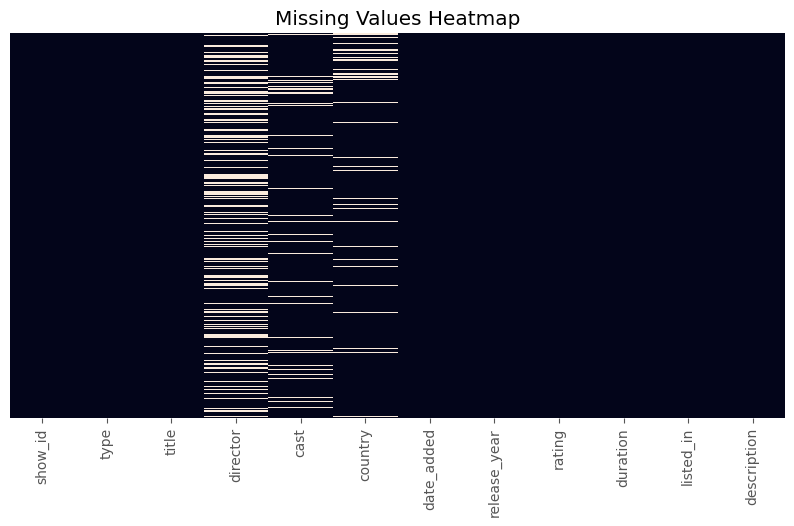

In [7]:
plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")

plt.show()

### Observation

The missing values heatmap reveals that the majority of missing data is concentrated in the Director, Cast, and Country columns.

Most other attributes contain complete information and can be directly used for analysis.

The Director column contains the highest number of missing values compared to other features.

### Business Insight

Missing values in Director and Cast information may affect content-specific analysis, while missing Country information may slightly impact geographical content distribution studies.

However, the overall dataset remains sufficiently complete for exploratory analysis.

In [8]:
missing_values = pd.DataFrame({
    'Column': df.columns,
    'Missing Values': df.isnull().sum(),
    'Percentage': round((df.isnull().sum()/len(df))*100,2)
})

missing_values.sort_values(
    by='Missing Values',
    ascending=False
)

,Column,Missing Values,Percentage
director,director,2634,29.91
country,country,831,9.44
cast,cast,825,9.37
date_added,date_added,10,0.11
rating,rating,4,0.05
duration,duration,3,0.03
show_id,show_id,0,0.00
type,type,0,0.00
title,title,0,0.00
release_year,release_year,0,0.00


### Interpretation

The Director column has the highest percentage of missing values, followed by Cast and Country. Since the missing percentage is relatively low compared to the total dataset size, the dataset remains suitable for exploratory analysis.

# 5. Content Type Distribution

This analysis compares the number of Movies and TV Shows available on Netflix.

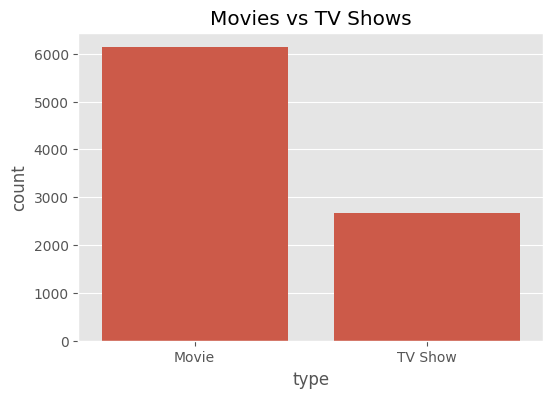

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='type',
    data=df
)

plt.title("Movies vs TV Shows")

plt.show()

### Observation

Movies account for a significantly larger share of Netflix's catalog compared to TV Shows.

This suggests that Netflix places greater emphasis on movie-based entertainment while maintaining a smaller but growing collection of TV series.

### Business Insight

Movies may attract a wider audience due to shorter viewing commitment compared to TV Shows.

# 6. Content Growth Over Time

To understand Netflix's expansion strategy, we analyze the number of titles added each year.

In [11]:
df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)

df['year_added'] = df['date_added'].dt.year

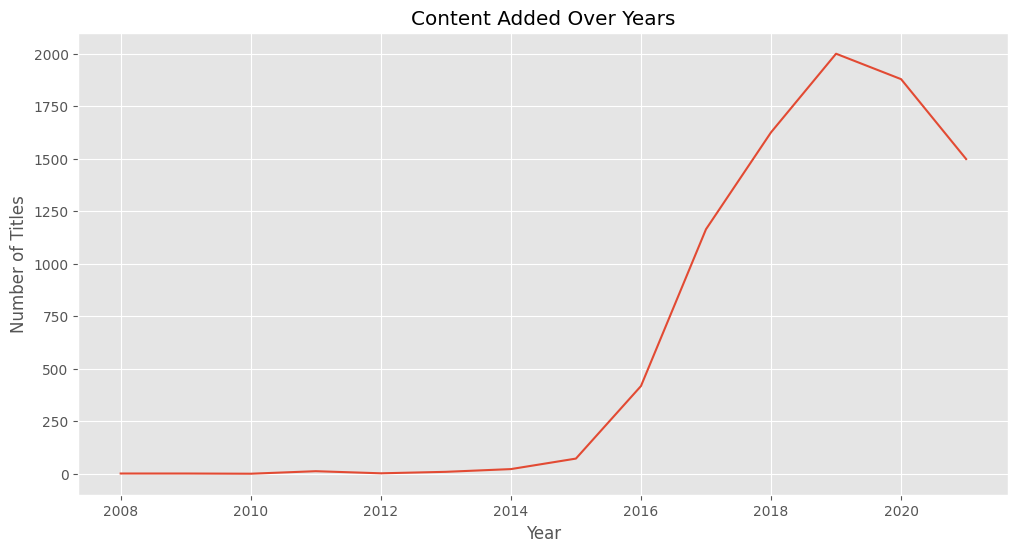

In [12]:
plt.figure(figsize=(12,6))

df['year_added'].value_counts().sort_index().plot()

plt.title("Content Added Over Years")

plt.xlabel("Year")

plt.ylabel("Number of Titles")

plt.show()

### Observation

Netflix experienced significant growth after 2015, with content additions increasing rapidly.

The highest number of titles were added around 2019.

### Business Insight

Netflix aggressively expanded its content library during this period to support global growth and subscriber acquisition.

# 7. Top Content Producing Countries

This analysis identifies the countries contributing the highest amount of content to Netflix.

In [14]:
top_countries = (
    df['country']
    .dropna()
    .str.split(',')
    .explode()
)

top_countries = top_countries.value_counts().head(10)

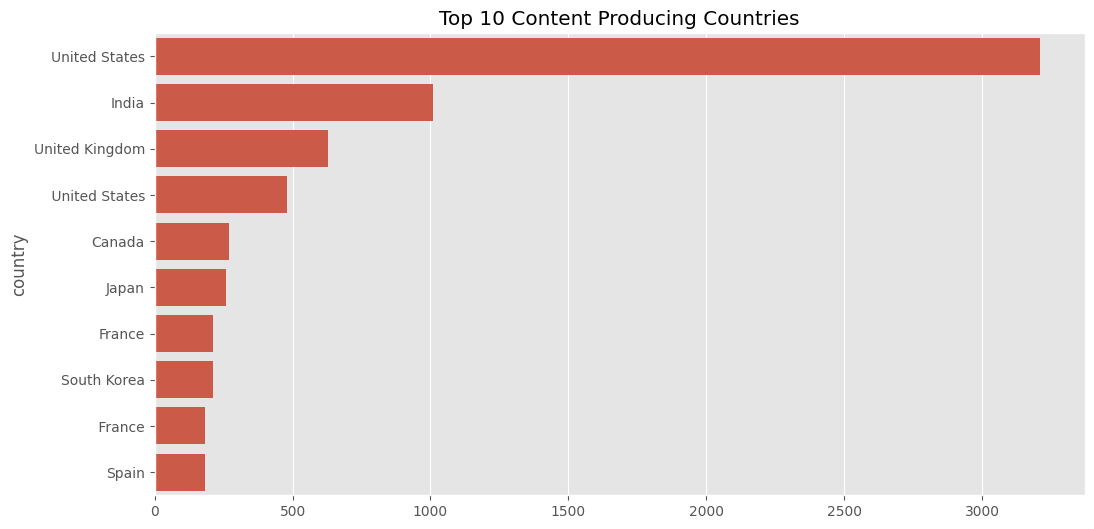

In [15]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Content Producing Countries")

plt.show()

### Observation

The United States contributes the highest amount of content on Netflix.

India and the United Kingdom are also major contributors.

### Business Insight

Netflix relies heavily on content from a few dominant countries while also expanding internationally.

# 8. Release Year Analysis

This analysis explores how Netflix content is distributed across different release years.

Understanding release trends helps identify whether Netflix focuses more on recent or older content.

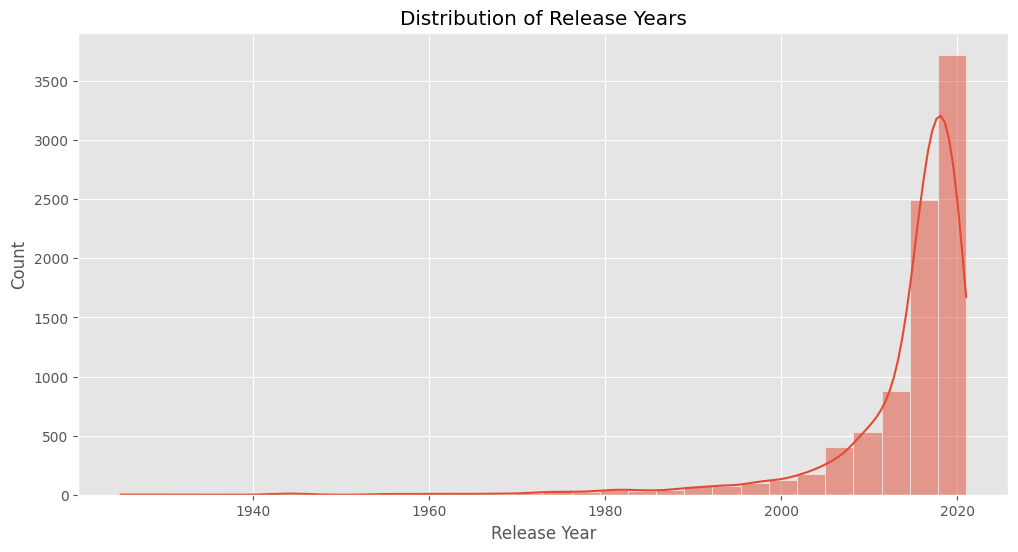

In [16]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['release_year'],
    bins=30,
    kde=True
)

plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Count")

plt.show()

### Observation

The majority of Netflix titles were released after 2000, with a sharp increase in content from the last decade.

Older titles are present but represent a much smaller portion of the catalog.

### Business Insight

Netflix prioritizes modern content to align with current audience preferences and viewing trends.

# 9. Content Ratings Analysis

This analysis examines the distribution of content ratings available on Netflix.

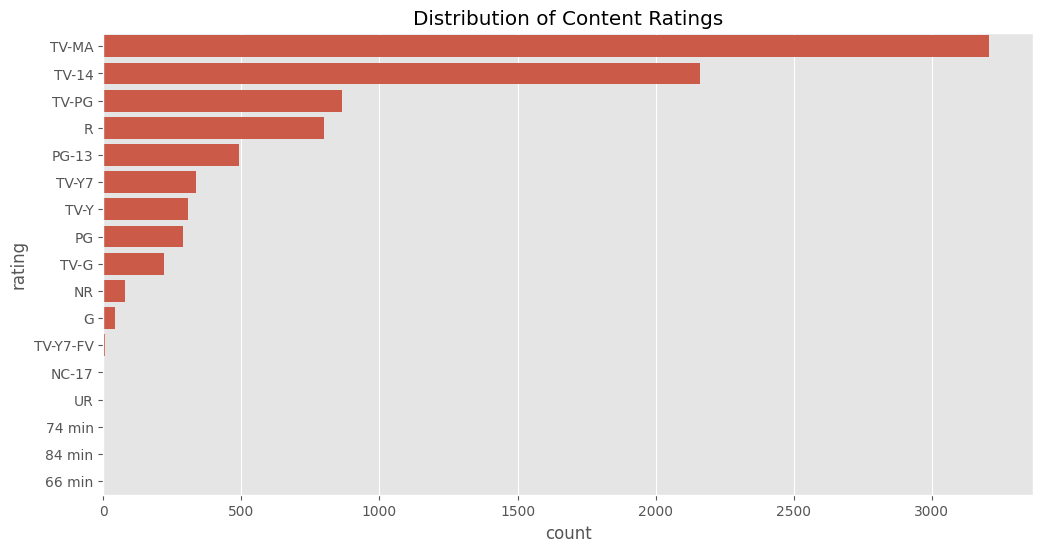

In [17]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index
)

plt.title("Distribution of Content Ratings")

plt.show()

### Observation

TV-MA and TV-14 are among the most common ratings on Netflix.

This indicates a significant amount of content targeted toward mature audiences.

### Business Insight

Netflix serves a broad audience but appears to focus heavily on teenage and adult viewers.

# 10. Genre Analysis

This analysis identifies the most common content genres available on Netflix.

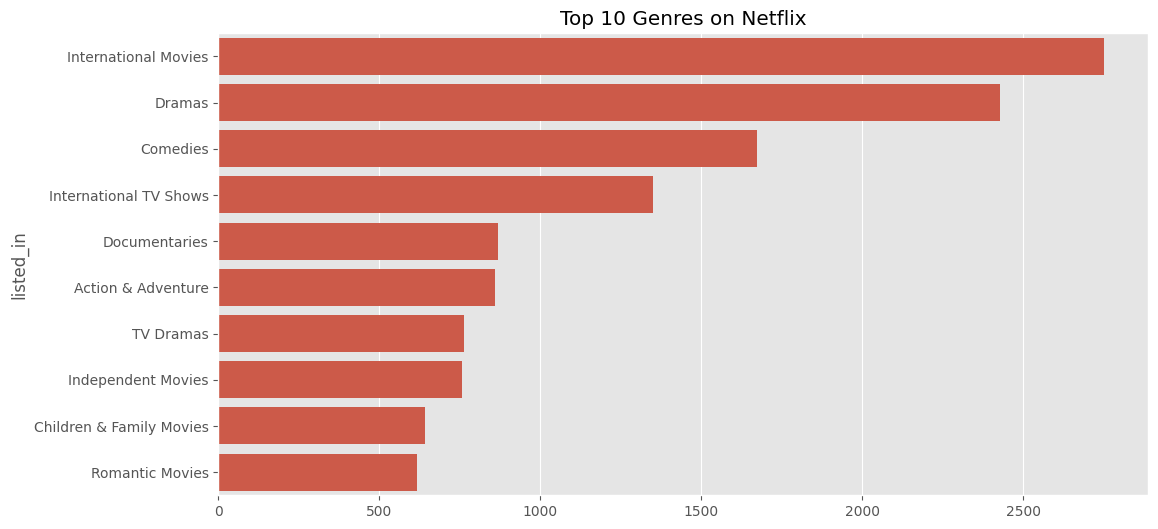

In [18]:
genres = df['listed_in'].str.split(', ').explode()

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Genres on Netflix")

plt.show()

### Observation

International Movies, Dramas, and Comedies appear most frequently in the dataset.

This indicates that Netflix maintains a diverse content portfolio while strongly focusing on globally appealing genres.

### Business Insight

A diverse genre portfolio allows Netflix to attract users with different entertainment preferences.

# 11. Movie Duration Analysis

This section explores the duration distribution of Netflix movies.

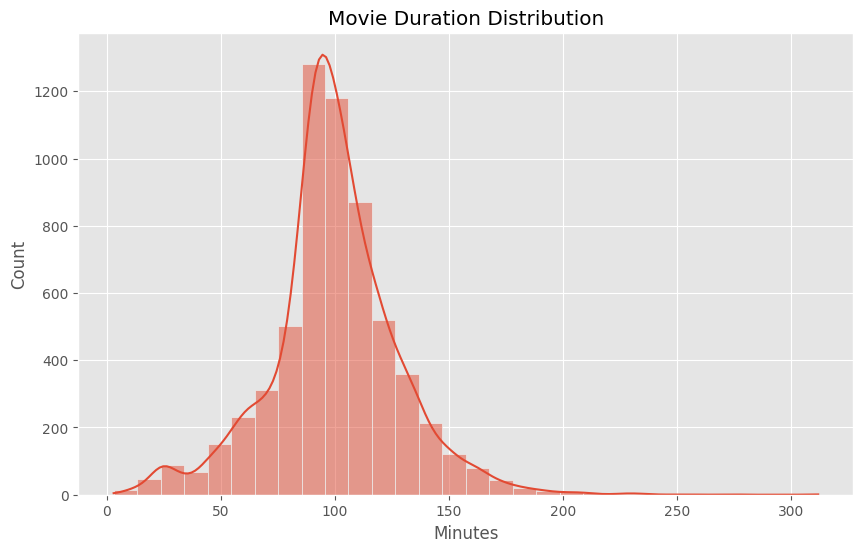

In [19]:
movies = df[df['type'] == 'Movie'].copy()

movies['duration'] = movies['duration'].str.replace(' min','')
movies['duration'] = pd.to_numeric(movies['duration'])

plt.figure(figsize=(10,6))

sns.histplot(
    movies['duration'],
    bins=30,
    kde=True
)

plt.title("Movie Duration Distribution")

plt.xlabel("Minutes")

plt.show()

### Observation

Most Netflix movies fall within the 80–120 minute duration range.

### Business Insight

Standard movie lengths remain the preferred format for audience engagement.

# 12. Top Directors on Netflix

This analysis identifies directors with the highest number of titles on Netflix.

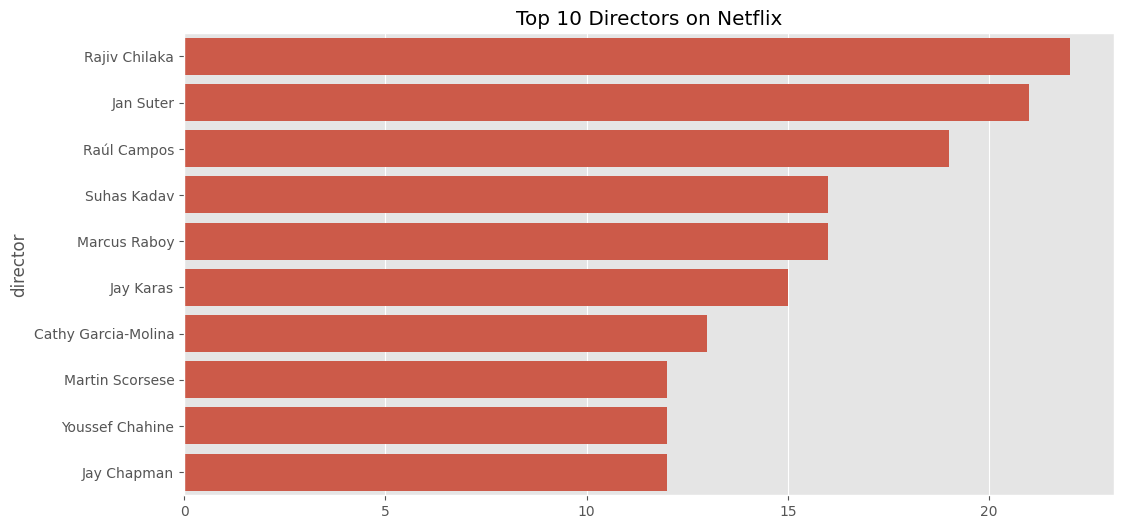

In [20]:
directors = df['director'].dropna().str.split(', ').explode()

top_directors = directors.value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)

plt.title("Top 10 Directors on Netflix")

plt.show()

### Observation

A limited number of directors contribute multiple titles to the Netflix platform, while most directors appear only once or twice.

This highlights the diversity of content creators represented in the catalog.

# 13. Most Frequent Actors

This section identifies actors who appear most frequently in Netflix content.

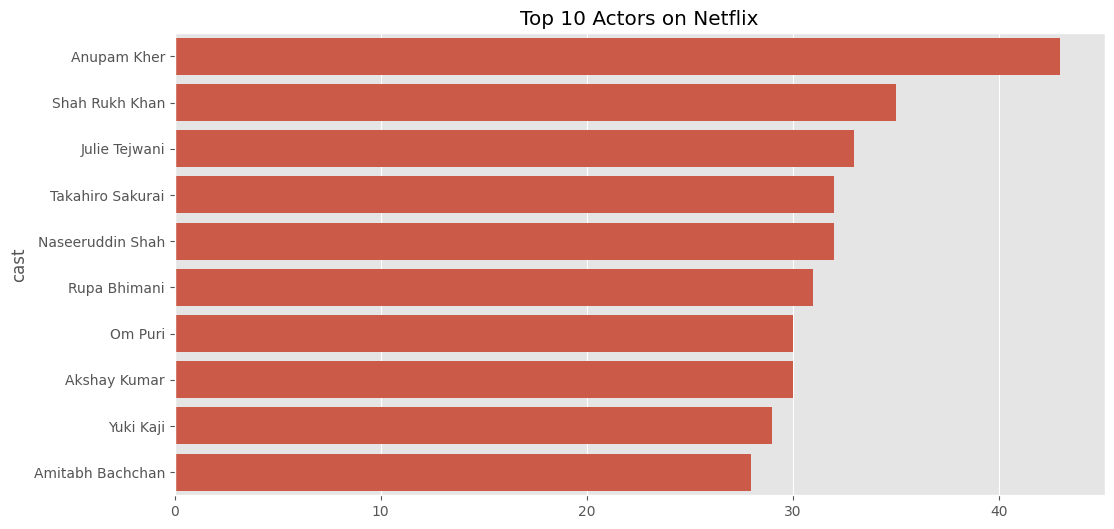

In [21]:
actors = df['cast'].dropna().str.split(', ').explode()

top_actors = actors.value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_actors.values,
    y=top_actors.index
)

plt.title("Top 10 Actors on Netflix")

plt.show()

### Observation

Several actors appear repeatedly across Netflix titles, indicating recurring collaborations and strong representation within the platform's content library.

# Executive Summary

## Key Findings

1. Movies dominate the Netflix content library.

2. Content additions increased rapidly after 2015.

3. The United States contributes the highest amount of content.

4. International Movies, Dramas, and Comedies are the most common genres.

5. Most content targets mature audiences through TV-MA and TV-14 ratings.

6. Movie durations are generally concentrated between 80 and 120 minutes.

7. Netflix has expanded aggressively in recent years through diversified global content.

### Overall Insight

The analysis reveals that Netflix's growth strategy is driven by large-scale content expansion, international diversification, and a strong focus on modern entertainment preferences.

# Business Recommendations

- Continue investing in high-performing genres such as Drama and Comedy.

- Expand content production partnerships beyond dominant countries.

- Maintain focus on modern content while preserving classic titles.

- Strengthen audience engagement through regional and international productions.

- Use viewer preferences to optimize future content acquisition strategies.

# Conclusion

This Exploratory Data Analysis successfully identified major trends, patterns, and characteristics within Netflix's content library.

The analysis highlighted content growth trends, geographical distribution, audience targeting, genre popularity, and content duration patterns.

These insights can support strategic business decisions, content planning, and future recommendation systems.